<a href="https://colab.research.google.com/github/sumitchy/Data-Science-Assessment-Project/blob/main/RetailChain_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# fetch dataset
online_retail = fetch_ucirepo(id=352)

# data (as pandas dataframes)
X = online_retail.data.features
y = online_retail.data.targets

# metadata
print(online_retail.metadata)

# variable information
print(online_retail.variables)


{'uci_id': 352, 'name': 'Online Retail', 'repository_url': 'https://archive.ics.uci.edu/dataset/352/online+retail', 'data_url': 'https://archive.ics.uci.edu/static/public/352/data.csv', 'abstract': 'This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 541909, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': None, 'index_col': ['InvoiceNo', 'StockCode'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Oct 21 2024', 'dataset_doi': '10.24432/C5BW33', 'creators': ['Daqing Chen'], 'intro_paper': {'ID': 361, 'type': 'NATIVE', 'title': 'Data mining for the online retail industry: A case study of RFM model-based customer segmenta

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,708 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,299 kB]
Fetched 5,140 kB in 2s (3,324 kB/s)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
63 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skippin

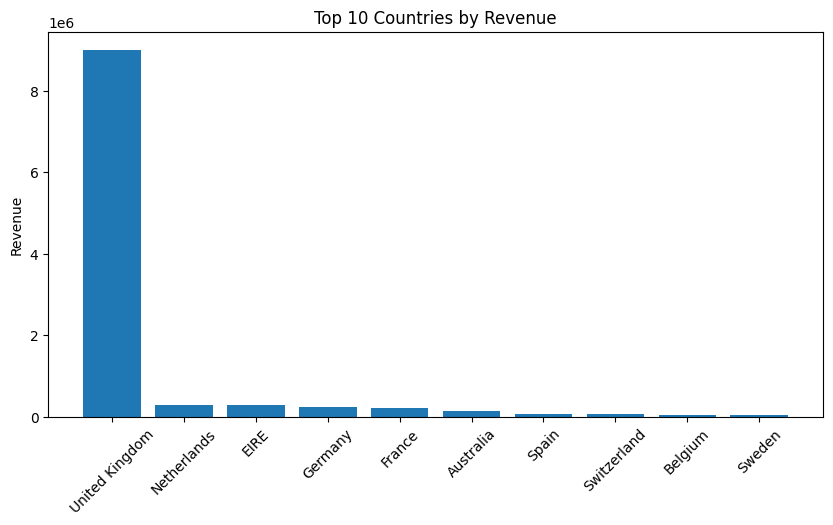

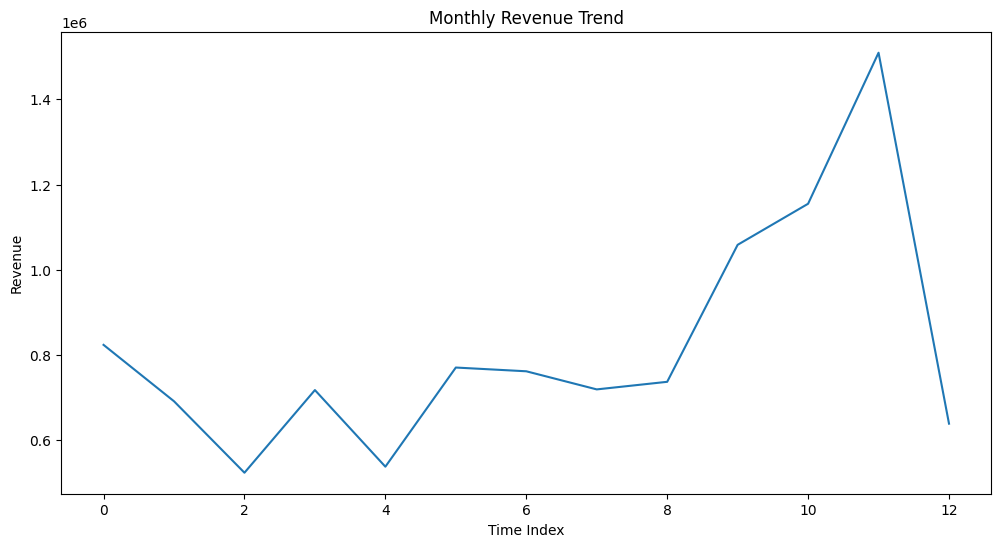

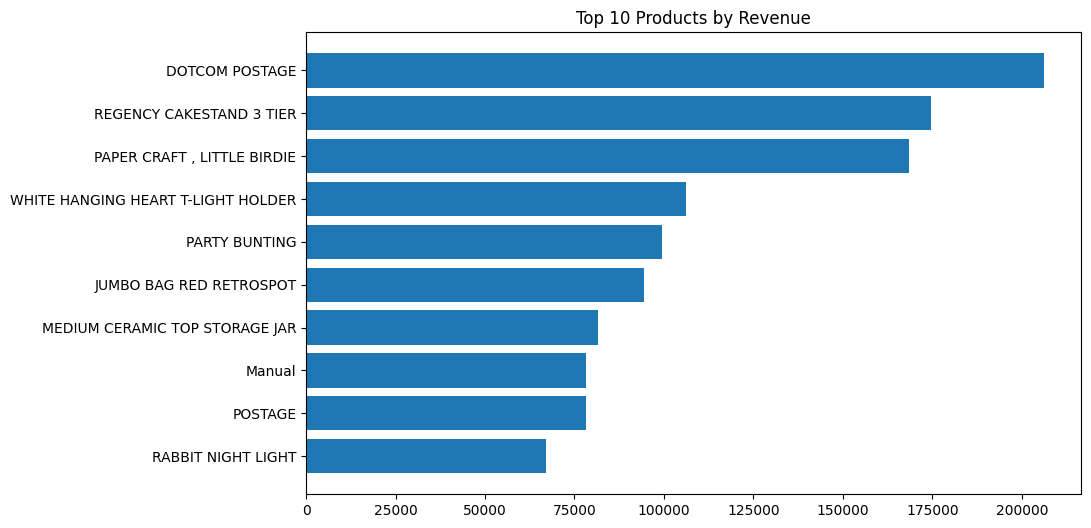

+----------+------------------+
|CustomerID|     Total_Revenue|
+----------+------------------+
|       NaN|1733152.5200001427|
|   14646.0| 280206.0199999992|
|   18102.0|259657.29999999993|
|   17450.0|194550.78999999998|
|   16446.0|          168472.5|
|   14911.0|143825.05999999988|
|   12415.0| 124914.5299999998|
|   14156.0|         117379.63|
|   17511.0| 91062.37999999995|
|   16029.0| 81024.84000000003|
+----------+------------------+



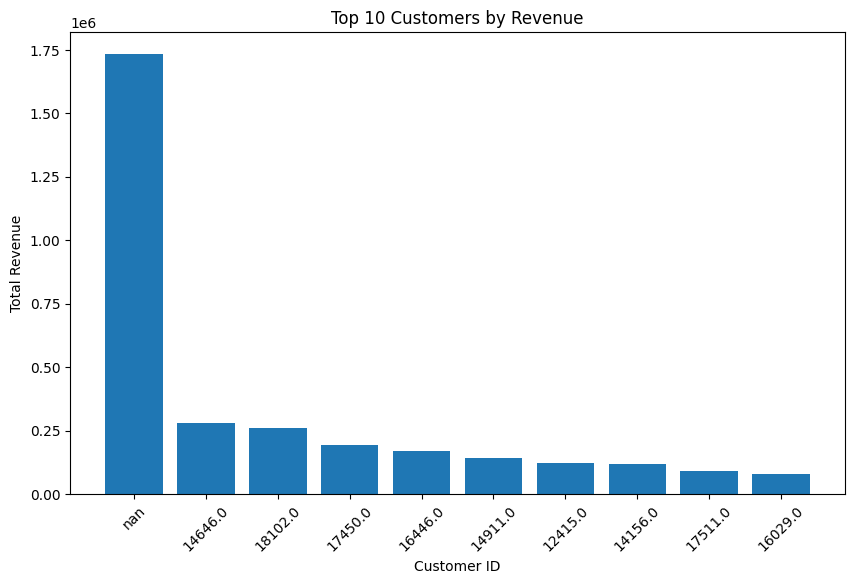

In [ ]:
# ==========================================
# 1️ Install & Setup Spark
# ==========================================
!sudo apt update -y
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget https://dlcdn.apache.org/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz
!tar xf spark-3.5.1-bin-hadoop3.tgz
!pip install -q findspark pyspark py4j ucimlrepo

import findspark
findspark.init()

from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import pandas as pd # Import pandas for concatenation

# ==========================================
# 2️ Start Spark Session
# ==========================================
sspark = SparkSession.builder \
    .appName("Online Retail Analytics - Spark Demo") \
    .getOrCreate()

# ==========================================
# 3️ Load UCI Online Retail Dataset
# ==========================================
online_retail = fetch_ucirepo(id=352)

# Convert pandas → Spark
# Combine features and IDs to ensure all necessary columns are present
pdf = pd.concat([online_retail.data.ids, online_retail.data.features], axis=1)
df = sspark.createDataFrame(pdf) # Corrected: use sspark instead of spark

df.show(5)

# ==========================================
# 4️ Data Cleaning
# ==========================================
# Remove cancelled transactions (Invoice starting with 'C')
df = df.filter(~F.col("InvoiceNo").startswith("C"))

# Create Revenue column
df = df.withColumn("Revenue", F.col("Quantity") * F.col("UnitPrice"))

# Convert date column
df = df.withColumn("InvoiceDate", F.to_timestamp("InvoiceDate", 'M/d/yyyy H:mm')) # Corrected: Changed MM to M and HH to H for flexibility

# Extract Year & Month
df = df.withColumn("Year", F.year("InvoiceDate"))
df = df.withColumn("Month", F.month("InvoiceDate"))

# ==========================================
# 5️ Top 10 Countries by Revenue
# ==========================================
country_sales = df.groupBy("Country") \
    .agg(F.sum("Revenue").alias("Total_Revenue")) \
    .orderBy(F.desc("Total_Revenue")) \
    .limit(10)

country_pd = country_sales.toPandas()

plt.figure(figsize=(10,5))
plt.bar(country_pd["Country"], country_pd["Total_Revenue"])
plt.xticks(rotation=45)
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.show()

# ==========================================
# 6️ Monthly Sales Trend (Seasonal Demand)
# ==========================================
monthly_sales = df.groupBy("Year", "Month") \
    .agg(F.sum("Revenue").alias("Monthly_Revenue")) \
    .orderBy("Year", "Month")

monthly_pd = monthly_sales.toPandas()

plt.figure(figsize=(12,6))
plt.plot(range(len(monthly_pd)), monthly_pd["Monthly_Revenue"])
plt.title("Monthly Revenue Trend")
plt.xlabel("Time Index")
plt.ylabel("Revenue")
plt.show()

# ==========================================
# 7️ Top 10 Products by Revenue
# ==========================================
top_products = df.groupBy("Description") \
    .agg(F.sum("Revenue").alias("Total_Revenue")) \
    .orderBy(F.desc("Total_Revenue")) \
    .limit(10)

products_pd = top_products.toPandas()

plt.figure(figsize=(10,6))
plt.barh(products_pd["Description"], products_pd["Total_Revenue"])
plt.gca().invert_yaxis()
plt.title("Top 10 Products by Revenue")
plt.show()

# ==========================================
# 8 Top 10 Customers by Revenue
# ==========================================

# Ensure Revenue column exists
df = df.withColumn("Revenue", F.col("Quantity") * F.col("UnitPrice"))

# Remove null CustomerID values (if any)
df_clean = df.filter(F.col("CustomerID").isNotNull())

# Aggregate revenue per customer
top_customers = df_clean.groupBy("CustomerID") \
    .agg(F.sum("Revenue").alias("Total_Revenue")) \
    .orderBy(F.desc("Total_Revenue")) \
    .limit(10)

top_customers.show()

# Convert to Pandas for visualization
top_customers_pd = top_customers.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(top_customers_pd["CustomerID"].astype(str),
        top_customers_pd["Total_Revenue"])
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()


In [ ]:
print("Data for Top 10 Countries by Revenue (Spark DataFrame):")
country_sales.show()
print("\nData for Monthly Sales Trend (Spark DataFrame):")
monthly_sales.show()
print("\nData for Top 10 Products by Revenue (Spark DataFrame):")
top_products.show()
print("\nData for Top 10 Customers by Revenue (Spark DataFrame):")
top_customers.show()

Data for Top 10 Countries by Revenue (Spark DataFrame):
+--------------+------------------+
|       Country|     Total_Revenue|
+--------------+------------------+
|United Kingdom| 9003097.963999141|
|   Netherlands|285446.33999999904|
|          EIRE| 283453.9599999982|
|       Germany|228867.13999999984|
|        France|209715.11000000022|
|     Australia| 138521.3099999998|
|         Spain| 61577.11000000025|
|   Switzerland| 57089.90000000011|
|       Belgium| 41196.33999999998|
|        Sweden| 38378.32999999999|
+--------------+------------------+


Data for Monthly Sales Trend (Spark DataFrame):
+----+-----+------------------+
|Year|Month|   Monthly_Revenue|
+----+-----+------------------+
|2010|   12| 823746.1399999646|
|2011|    1| 691364.5600000108|
|2011|    2| 523631.8900000278|
|2011|    3| 717639.3600000187|
|2011|    4| 537808.6210000243|
|2011|    5| 770536.0200000107|
|2011|    6| 761739.9000000219|
|2011|    7| 719221.1910000187|
|2011|    8| 737014.2600000158|
|2011|